<a href="https://colab.research.google.com/github/xyz111131/AI-Tools-for-Statistical-Research/blob/main/autograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z)
loss = F.binary_cross_entropy(a, y)

loss.backward()

print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


In [ ]:
import torch

learning_rate = 0.01

# Manually update weights using gradient descent
with torch.no_grad(): # Disable gradient computation for these operations
    w1 -= learning_rate * w1.grad
    b -= learning_rate * b.grad

    # Zero the gradients after updating
    w1.grad.zero_()
    b.grad.zero_()

print(f"Updated w1: {w1}")
print(f"Updated b: {b}")

Updated w1: tensor([2.2009], requires_grad=True)
Updated b: tensor([0.0008], requires_grad=True)


In [ ]:
!pip install torchviz

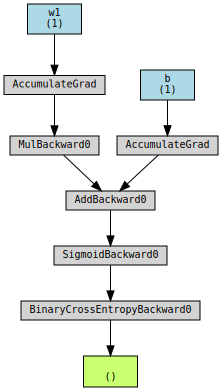

In [ ]:

#!apt-get install graphviz
import torchviz

# Assuming 'loss', 'w1', and 'b' are defined from previous cells

dot = torchviz.make_dot(loss, params={'w1': w1, 'b': b})

# To display the graph in the notebook (requires graphviz to be installed and in PATH)
dot

# To save the graph as a PDF file
# dot.render("compute_graph", format="pdf", cleanup=True)

# To save the graph as a PNG file
# dot.render("compute_graph", format="png", cleanup=True)

### 2. Modern JIT: torch.compile (PyTorch 2.0+)
`torch.compile` is the modern approach. It uses a custom backend (TorchInductor) to generate optimized kernels (often using OpenAI Triton) for your specific hardware without requiring you to rewrite code into a subset of Python like TorchScript.

In [6]:
import torch
import time

# Define a compute-intensive function
def benchmark_fn(x):
    for _ in range(5):
        x = torch.sin(x) + torch.cos(x)
    return torch.sigmoid(x)

# Prepare data
size = 8192
device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.randn(size, size, device=device)

# 1. Eager Mode Benchmark
# Warm up
for _ in range(5): _ = benchmark_fn(x)

start_eager = time.time()
for _ in range(20):
    _ = benchmark_fn(x)
if device == "cuda": torch.cuda.synchronize()
eager_time = (time.time() - start_eager) / 20

# 2. torch.compile Benchmark
compiled_fn = torch.compile(benchmark_fn)
# Warm up (compilation happens here)
_ = compiled_fn(x)

start_compile = time.time()
for _ in range(20):
    _ = compiled_fn(x)
if device == "cuda": torch.cuda.synchronize()
compile_time = (time.time() - start_compile) / 20

print(f"Device: {device}")
print(f"Average Eager Time:   {eager_time:.6f}s")
print(f"Average Compile Time: {compile_time:.6f}s")
print(f"Speedup: {eager_time / compile_time:.2f}x")

Device: cuda
Average Eager Time:   0.050330s
Average Compile Time: 0.006606s
Speedup: 7.62x


Why is it faster?
**Kernel Fusion:** In Eager mode, each operation (like sin, cos, and +) is a separate GPU kernel call. torch.compile fuses these into a single optimized kernel, reducing the overhead of launching many small tasks and minimizing memory reads/writes.
**Triton Integration:** It uses the OpenAI Triton compiler to generate highly efficient machine code specifically tailored for your GPU architecture.
**Reduced Python Overhead:** By compiling the function logic, PyTorch bypasses much of the Python interpreter's overhead during the main execution loop.